# 02 — Construction et analyse du réseau d'interaction des cytokines

**Objectif de ce notebook :**
1. Charger les données récupérées via `01_data_collection.py` (UniProt + STRING)
2. Construire le graphe d'interactions avec `NetworkX`
3. Visualiser le réseau
4. Calculer les mesures de centralité pour identifier les cytokines les plus "importantes" du réseau

**Données utilisées :**
- `data/raw/string_network.csv` — les interactions entre cytokines (nœuds + arêtes)
- `data/raw/uniprot_annotations.csv` — les annotations biologiques (pour légender les nœuds)

## 1. Imports et chargement des données

In [10]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Chargement des fichiers générés par le script de collecte
network_df = pd.read_csv("../data/raw/string_network.csv")
annotations_df = pd.read_csv("../data/raw/uniprot_annotations.csv")

print(f"Nombre d'interactions chargées : {len(network_df)}")
print(f"Nombre de cytokines annotées : {len(annotations_df)}")
network_df.head()

Nombre d'interactions chargées : 147
Nombre de cytokines annotées : 21


,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
0,9606.ENSP00000221930,9606.ENSP00000226730,TGFB1,IL2,9606,0.763,0,0,0.0,0.000,0.0,0.0,0.763
1,9606.ENSP00000221930,9606.ENSP00000306512,TGFB1,CXCL8,9606,0.775,0,0,0.0,0.085,0.0,0.0,0.765
2,9606.ENSP00000221930,9606.ENSP00000304915,TGFB1,IL13,9606,0.816,0,0,0.0,0.054,0.0,0.0,0.814
3,9606.ENSP00000221930,9606.ENSP00000225831,TGFB1,CCL2,9606,0.851,0,0,0.0,0.086,0.0,0.0,0.843
4,9606.ENSP00000221930,9606.ENSP00000231449,TGFB1,IL4,9606,0.852,0,0,0.0,0.056,0.0,0.0,0.850


## 2. Inspection rapide des données

Avant de construire le graphe, on vérifie toujours que les données sont cohérentes : 
pas de valeurs manquantes critiques, scores dans une plage attendue, etc.

In [11]:
print("Colonnes disponibles :", list(network_df.columns))
print("\nValeurs manquantes par colonne :")
print(network_df.isna().sum())
print("\nStatistiques du score de confiance :")
print(network_df["score"].describe())

Colonnes disponibles : ['stringId_A', 'stringId_B', 'preferredName_A', 'preferredName_B', 'ncbiTaxonId', 'score', 'nscore', 'fscore', 'pscore', 'ascore', 'escore', 'dscore', 'tscore']

Valeurs manquantes par colonne :
stringId_A         0
stringId_B         0
preferredName_A    0
preferredName_B    0
ncbiTaxonId        0
score              0
nscore             0
fscore             0
pscore             0
ascore             0
escore             0
dscore             0
tscore             0
dtype: int64

Statistiques du score de confiance :
count    147.000000
mean       0.920510
std        0.078904
min        0.702000
25%        0.861500
50%        0.953000
75%        0.983500
max        0.999000
Name: score, dtype: float64


## 3. Construction du graphe avec NetworkX

Chaque cytokine devient un **nœud**. Chaque interaction connue entre deux cytokines
devient une **arête**, pondérée par le score de confiance STRING (`score`, entre 0 et 1).

On utilise un graphe **non orienté** (`nx.Graph`) car une interaction protéine-protéine
n'a pas de "sens" (A interagit avec B = B interagit avec A).

In [12]:
G = nx.from_pandas_edgelist(
    network_df,
    source="preferredName_A",
    target="preferredName_B",
    edge_attr="score",
    create_using=nx.Graph()
)

print(f"Nombre de nœuds (cytokines) : {G.number_of_nodes()}")
print(f"Nombre d'arêtes (interactions) : {G.number_of_edges()}")
print(f"Densité du réseau : {nx.density(G):.3f}")
print(f"Le réseau est-il connexe (tout relié) ? {nx.is_connected(G)}")

Nombre de nœuds (cytokines) : 21
Nombre d'arêtes (interactions) : 147
Densité du réseau : 0.700
Le réseau est-il connexe (tout relié) ? True


**Note d'interprétation** — La *densité* mesure la proportion d'interactions présentes par rapport à toutes
les interactions possibles (entre 0 et 1). Un réseau biologique réel est presque toujours "clairsemé" 
(densité faible), ce qui est normal : toutes les protéines n'interagissent pas avec toutes les autres.

Si `is_connected` est `False`, cela signifie qu'au moins une cytokine n'a aucune interaction connue 
avec les autres dans notre liste (nœud isolé) — on le vérifie juste en dessous.

In [13]:
# Identifier les cytokines isolées (aucune interaction trouvée dans notre panel)
all_cytokines = set(annotations_df["gene_name"])
connected_cytokines = set(G.nodes())
isolated = all_cytokines - connected_cytokines

if isolated:
    print(f"Cytokines sans interaction trouvée dans le réseau : {isolated}")
else:
    print("Toutes les cytokines du panel ont au moins une interaction.")

Toutes les cytokines du panel ont au moins une interaction.


## 4. Visualisation du réseau

On utilise l'algorithme `spring_layout` (force-directed) : les nœuds fortement connectés
se rapprochent naturellement, les nœuds peu connectés s'éloignent. C'est la façon standard
de visualiser un petit réseau biologique.

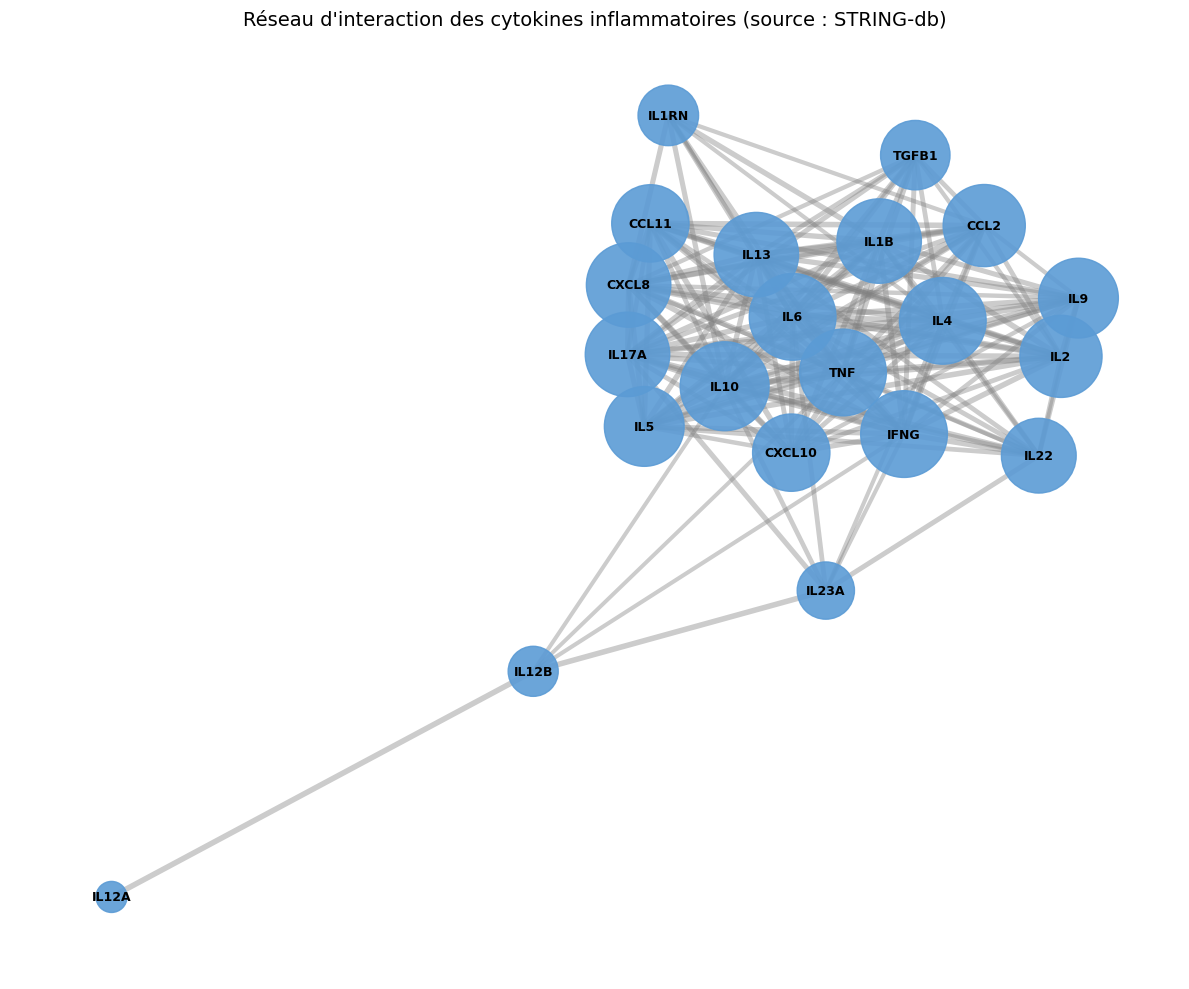

In [14]:
plt.figure(figsize=(12, 10))

# Position des nœuds : seed fixe pour un résultat reproductible
pos = nx.spring_layout(G, seed=42, k=0.6)

# Taille des nœuds proportionnelle au nombre de connexions (degré)
degrees = dict(G.degree())
node_sizes = [degrees[node] * 200 + 300 for node in G.nodes()]

# Épaisseur des arêtes proportionnelle au score de confiance
edge_weights = [G[u][v]["score"] * 4 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#5B9BD5", alpha=0.9)
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.4, edge_color="gray")
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

plt.title("Réseau d'interaction des cytokines inflammatoires (source : STRING-db)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.savefig("../data/processed/network_overview.png", dpi=200)
plt.show()

**Lecture du graphique :**
- Plus un nœud (cercle) est **gros**, plus la cytokine correspondante a d'interactions connues avec les autres.
- Plus une arête (trait) est **épaisse**, plus l'interaction est fiable (score de confiance STRING élevé).
- Les cytokines proches les unes des autres sur le dessin interagissent davantage entre elles.

## 5. Mesures de centralité — identifier les cytokines les plus "importantes"

Trois mesures classiques, chacune répondant à une question différente :

- **Degree centrality** : "Combien de connexions directes cette cytokine a-t-elle ?" 
  → identifie les cytokines les plus "populaires".
- **Betweenness centrality** : "À quel point cette cytokine sert-elle de pont entre d'autres cytokines ?" 
  → identifie les cytokines qui relient des groupes autrement peu connectés entre eux.
- **Eigenvector centrality** : "Cette cytokine est-elle connectée à d'autres cytokines elles-mêmes importantes ?" 
  → une version plus "qualitative" du degree centrality.

In [15]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, weight="score")

# eigenvector centrality peut ne pas converger sur certains graphes peu connectés
try:
    eigenvector_centrality = nx.eigenvector_centrality(G, weight="score", max_iter=1000)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality n'a pas convergé (réseau probablement trop fragmenté).")
    eigenvector_centrality = {node: None for node in G.nodes()}

centrality_df = pd.DataFrame({
    "cytokine": list(G.nodes()),
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "betweenness_centrality": [betweenness_centrality[n] for n in G.nodes()],
    "eigenvector_centrality": [eigenvector_centrality[n] for n in G.nodes()],
}).sort_values("degree_centrality", ascending=False).reset_index(drop=True)

centrality_df

,cytokine,degree_centrality,betweenness_centrality,eigenvector_centrality
0,IL10,0.95,0.021053,0.265496
1,IFNG,0.90,0.047368,0.257032
2,TNF,0.90,0.115789,0.255677
3,IL4,0.90,0.026316,0.260781
4,IL6,0.90,0.005263,0.264033
5,CXCL8,0.85,0.021053,0.251777
6,IL17A,0.85,0.000000,0.249311
7,IL1B,0.85,0.000000,0.260225
8,IL13,0.85,0.026316,0.250273
9,IL2,0.80,0.010526,0.246352


In [16]:
# Sauvegarde pour réutilisation dans les notebooks suivants (détection de communautés, etc.)
centrality_df.to_csv("../data/processed/centrality_scores.csv", index=False)
print("Sauvegardé dans data/processed/centrality_scores.csv")

Sauvegardé dans data/processed/centrality_scores.csv


## 6. Visualisation : les 10 cytokines les plus centrales

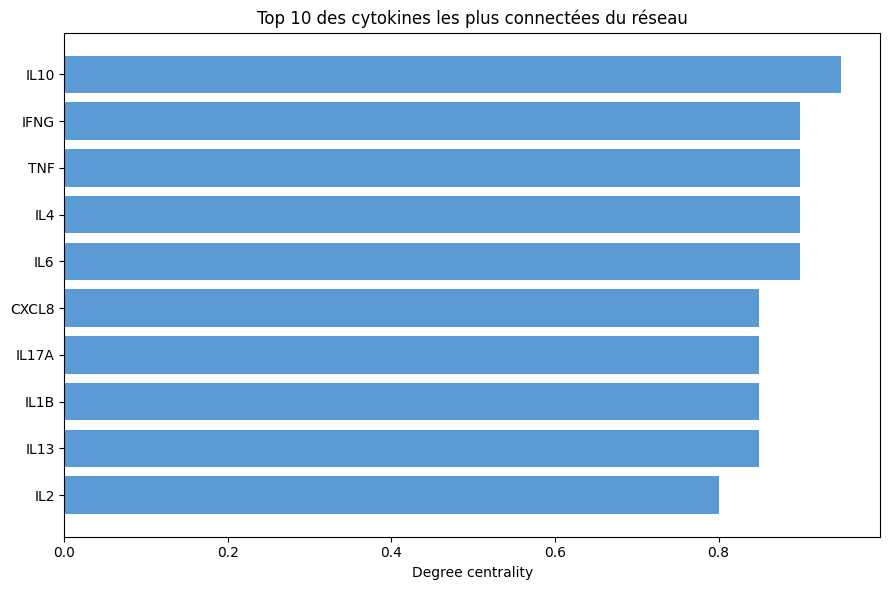

In [17]:
top10 = centrality_df.head(10)

plt.figure(figsize=(9, 6))
plt.barh(top10["cytokine"][::-1], top10["degree_centrality"][::-1], color="#5B9BD5")
plt.xlabel("Degree centrality")
plt.title("Top 10 des cytokines les plus connectées du réseau")
plt.tight_layout()
plt.savefig("../data/processed/top10_centrality.png", dpi=200)
plt.show()

## 7. Interprétation biologique rapide

On croise les cytokines les plus centrales avec leur fonction issue d'UniProt, 
pour donner du sens biologique au résultat mathématique.

In [18]:
top5_names = centrality_df.head(5)["cytokine"].tolist()

summary = annotations_df[annotations_df["gene_name"].isin(top5_names)][
    ["gene_name", "protein_name", "function"]
]

for _, row in summary.iterrows():
    print(f"### {row['gene_name']} ({row['protein_name']})")
    func = row["function"]
    print(func[:300] + ("..." if isinstance(func, str) and len(func) > 300 else ""))
    print()

### IL6 (Interleukin-6)
Cytokine with a wide variety of biological functions in immunity, tissue regeneration, and metabolism. Binds to IL6R, then the complex associates to the signaling subunit IL6ST/gp130 to trigger the intracellular IL6-signaling pathway (Probable). The interaction with the membrane-bound IL6R and IL6ST...

### TNF (Tumor necrosis factor)
Cytokine that binds to TNFRSF1A/TNFR1 and TNFRSF1B/TNFBR. It is mainly secreted by macrophages and can induce cell death of certain tumor cell lines. It is potent pyrogen causing fever by direct action or by stimulation of interleukin-1 secretion and is implicated in the induction of cachexia, Under...

### IL10 (Interleukin-10)
Major immune regulatory cytokine that acts on many cells of the immune system where it has profound anti-inflammatory functions, limiting excessive tissue disruption caused by inflammation. Mechanistically, IL10 binds to its heterotetrameric receptor comprising IL10RA and IL10RB leading to JAK1 and ...

###

## Résumé de ce notebook

- Construit le graphe d'interaction à partir de `string_network.csv`
- Visualisé le réseau global
- Calculé et sauvegardé les scores de centralité (`data/processed/centrality_scores.csv`)
- Identifié et interprété les cytokines les plus centrales du réseau

**Prochaine étape (notebook 03) :** détection de communautés (algorithme de Louvain) 
pour identifier des sous-groupes fonctionnels de cytokines, puis interprétation via 
l'enrichissement fonctionnel (`string_enrichment.csv`).